## 2. Baseline Model Comparison

This notebook trains and evaluates XGBoost (default and tuned), AutoGluon, and TabPFN on the bank customer churn dataset. All experiments are repeated across 5 seeds (0-4) and results are reported as mean ± standard deviation. Statistical significance of performance differences is assessed using paired t-tests.

### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from utils import load_and_preprocess, evaluate_model, summarize_results, get_train_test_split

os.makedirs('figures', exist_ok=True)
SEEDS = [0, 1, 2, 3, 4]
plt.rcParams['font.size'] = 12
print('Setup complete!')

Setup complete!


### Data Loading and Preprocessing
Load the dataset using the shared preprocessing utility. XGBoost requires one-hot encoded features; AutoGluon and TabPFN handle categorical variables internally.

In [2]:
X_xgb, X_auto, y = load_and_preprocess('Churn_Modelling.csv')
X_tabpfn = X_auto.copy()

print(f'XGBoost features: {X_xgb.shape[1]}')
print(f'AutoGluon/TabPFN features: {X_auto.shape[1]}')

XGBoost features: 13
AutoGluon/TabPFN features: 10


### XGBoost (Default)
Train XGBoost with default hyperparameters across 5 seeds to establish an out-of-the-box baseline.

In [3]:
from xgboost import XGBClassifier

xgb_results = []

for seed in SEEDS:
    X_train, X_test, y_train, y_test = get_train_test_split(X_xgb.astype(float), y, seed)

    start = time.time()
    model = XGBClassifier(random_state=seed, eval_metric='logloss')
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    inference_time = time.time() - start

    xgb_results.append(evaluate_model(y_test, y_pred, y_prob, train_time, inference_time, seed))

xgb_df = pd.DataFrame(xgb_results)
summarize_results(xgb_df, 'XGBoost (Default)')


XGBoost (Default) Results (mean ± std across seeds):
  accuracy: 0.8524 ± 0.0072
  auc_roc: 0.8373 ± 0.0114
  f1: 0.5678 ± 0.0236
  train_time: 0.1500s
  inference_time: 0.0023s


### XGBoost (Tuned)
Optimize XGBoost hyperparameters using Optuna with 50 trials and 3-fold cross-validation. The best parameters are then evaluated across 5 seeds.

In [4]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train_tune, _, y_train_tune, _ = get_train_test_split(X_xgb.astype(float), y, seed=0)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss', 'random_state': 42
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train_tune, y_train_tune, cv=3, scoring='roc_auc').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Best params:', study.best_params)
print('Best CV AUC:', study.best_value)

  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 251, 'max_depth': 6, 'learning_rate': 0.012222561171485218, 'subsample': 0.6067752182897136, 'colsample_bytree': 0.6973725458747699}
Best CV AUC: 0.8683311823433701


In [5]:
tuned_xgb_results = []
best_params = {**study.best_params, 'eval_metric': 'logloss'}

for seed in SEEDS:
    X_train, X_test, y_train, y_test = get_train_test_split(X_xgb.astype(float), y, seed)

    start = time.time()
    model = XGBClassifier(**best_params, random_state=seed)
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    inference_time = time.time() - start

    tuned_xgb_results.append(evaluate_model(y_test, y_pred, y_prob, train_time, inference_time, seed))

tuned_xgb_df = pd.DataFrame(tuned_xgb_results)
summarize_results(tuned_xgb_df, 'XGBoost (Tuned)')


XGBoost (Tuned) Results (mean ± std across seeds):
  accuracy: 0.8613 ± 0.0032
  auc_roc: 0.8658 ± 0.0061
  f1: 0.5493 ± 0.0169
  train_time: 0.3266s
  inference_time: 0.0027s


### AutoGluon
Train AutoGluon with high_quality preset and 120-second time limit across 5 seeds. No manual configuration is required.

In [6]:
from autogluon.tabular import TabularPredictor

auto_results = []

for seed in SEEDS:
    X_train, X_test, y_train, y_test = get_train_test_split(X_auto, y, seed)

    train_data = X_train.copy()
    train_data['Exited'] = y_train.values

    save_path = f'agmodels/seed_{seed}'
    if os.path.exists(save_path):
        shutil.rmtree(save_path)

    start = time.time()
    predictor = TabularPredictor(label='Exited', path=save_path, verbosity=0)
    predictor.fit(train_data, time_limit=120, presets='high_quality')
    train_time = time.time() - start

    start = time.time()
    y_prob = predictor.predict_proba(X_test)[1]
    y_pred = predictor.predict(X_test)
    inference_time = time.time() - start

    auto_results.append(evaluate_model(y_test, y_pred, y_prob, train_time, inference_time, seed))
    shutil.rmtree(save_path)

auto_df = pd.DataFrame(auto_results)
summarize_results(auto_df, 'AutoGluon')


AutoGluon Results (mean ± std across seeds):
  accuracy: 0.8635 ± 0.0046
  auc_roc: 0.8641 ± 0.0083
  f1: 0.5833 ± 0.0173
  train_time: 124.7536s
  inference_time: 0.5721s


### TabPFN (Cloud API)
Evaluate TabPFN via the official cloud API across 5 seeds. TabPFN performs zero-shot inference without any training on the target dataset.

In [7]:
from tabpfn_client import TabPFNClassifier as CloudTabPFN, init
init()  # Reuses existing token if available

Found existing access token, reusing it for authentication.

In [8]:
tabpfn_results = []

for seed in SEEDS:
    X_train, X_test, y_train, y_test = get_train_test_split(X_tabpfn, y, seed)

    start = time.time()
    model = CloudTabPFN(random_state=seed)
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    inference_time = time.time() - start

    tabpfn_results.append(evaluate_model(y_test, y_pred, y_prob, train_time, inference_time, seed))

tabpfn_df = pd.DataFrame(tabpfn_results)
summarize_results(tabpfn_df, 'TabPFN')

00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... -

00:03 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

...

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Predicting... -

00:01 Predicting... Done!

TabPFN Results (mean ± std across seeds):
  accuracy: 0.8687 ± 0.0030
  auc_roc: 0.8750 ± 0.0051
  f1: 0.6079 ± 0.0097
  train_time: 0.3062s
  inference_time: 3.4960s


### Results
Compare all models and assess statistical significance using paired t-tests.

In [9]:
summary = pd.DataFrame({
    'Model': ['XGBoost (Default)', 'XGBoost (Tuned)', 'AutoGluon', 'TabPFN'],
    'AUC-ROC': [
        f"{xgb_df['auc_roc'].mean():.4f} ± {xgb_df['auc_roc'].std():.4f}",
        f"{tuned_xgb_df['auc_roc'].mean():.4f} ± {tuned_xgb_df['auc_roc'].std():.4f}",
        f"{auto_df['auc_roc'].mean():.4f} ± {auto_df['auc_roc'].std():.4f}",
        f"{tabpfn_df['auc_roc'].mean():.4f} ± {tabpfn_df['auc_roc'].std():.4f}"
    ],
    'F1-Score': [
        f"{xgb_df['f1'].mean():.4f} ± {xgb_df['f1'].std():.4f}",
        f"{tuned_xgb_df['f1'].mean():.4f} ± {tuned_xgb_df['f1'].std():.4f}",
        f"{auto_df['f1'].mean():.4f} ± {auto_df['f1'].std():.4f}",
        f"{tabpfn_df['f1'].mean():.4f} ± {tabpfn_df['f1'].std():.4f}"
    ]
})
print(summary.to_string(index=False))

            Model         AUC-ROC        F1-Score
XGBoost (Default) 0.8373 ± 0.0114 0.5678 ± 0.0236
  XGBoost (Tuned) 0.8658 ± 0.0061 0.5493 ± 0.0169
        AutoGluon 0.8641 ± 0.0083 0.5833 ± 0.0173
           TabPFN 0.8750 ± 0.0051 0.6079 ± 0.0097


In [10]:
# Paired t-tests
comparisons = [
    ('Default vs Tuned XGBoost', xgb_df['auc_roc'], tuned_xgb_df['auc_roc']),
    ('Tuned XGBoost vs AutoGluon', tuned_xgb_df['auc_roc'], auto_df['auc_roc']),
    ('Tuned XGBoost vs TabPFN', tuned_xgb_df['auc_roc'], tabpfn_df['auc_roc']),
    ('AutoGluon vs TabPFN', auto_df['auc_roc'], tabpfn_df['auc_roc'])
]

print('Paired t-test results (AUC-ROC):')
for name, a, b in comparisons:
    stat, p = stats.ttest_rel(a, b)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f'  {name}: t={stat:.4f}, p={p:.4f}, Significant: {sig}')

Paired t-test results (AUC-ROC):
  Default vs Tuned XGBoost: t=-7.4748, p=0.0017, Significant: Yes
  Tuned XGBoost vs AutoGluon: t=1.0472, p=0.3541, Significant: No
  Tuned XGBoost vs TabPFN: t=-18.8264, p=0.0000, Significant: Yes
  AutoGluon vs TabPFN: t=-5.8353, p=0.0043, Significant: Yes


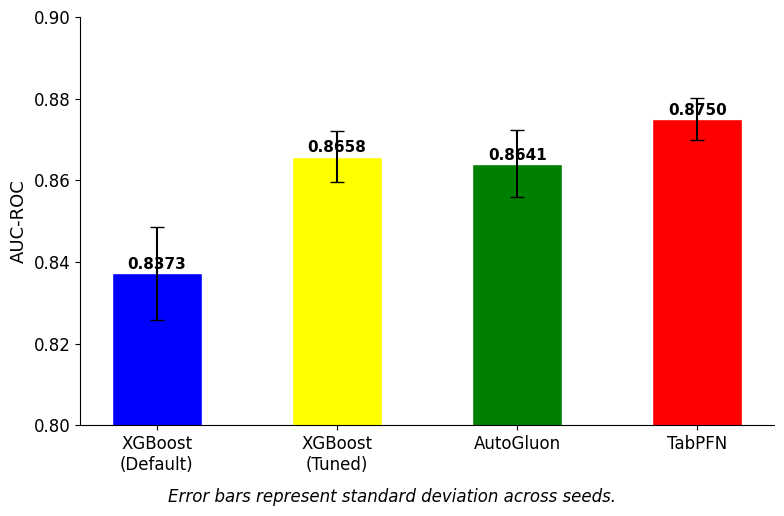

In [14]:
# Figure 4: AUC-ROC comparison
fig, ax = plt.subplots(figsize=(8, 5))

models = ['XGBoost\n(Default)', 'XGBoost\n(Tuned)', 'AutoGluon', 'TabPFN']
colors = ['blue', 'yellow', 'green', 'red']
auc_means = [xgb_df['auc_roc'].mean(), tuned_xgb_df['auc_roc'].mean(),
             auto_df['auc_roc'].mean(), tabpfn_df['auc_roc'].mean()]
auc_stds = [xgb_df['auc_roc'].std(), tuned_xgb_df['auc_roc'].std(),
            auto_df['auc_roc'].std(), tabpfn_df['auc_roc'].std()]

bars = ax.bar(models, auc_means, yerr=auc_stds,
              color=colors, edgecolor='white', capsize=5, width=0.5)
ax.set_ylabel('AUC-ROC', fontsize=13)
ax.set_ylim(0.80, 0.90)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, v in zip(bars, auc_means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
            f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
fig.text(0.5, -0.02, 'Error bars represent standard deviation across seeds.',
         ha='center', fontsize=12, style='italic')
plt.tight_layout()
plt.savefig('figures/figure4_aucroc.png', dpi=150, bbox_inches='tight')
plt.show()

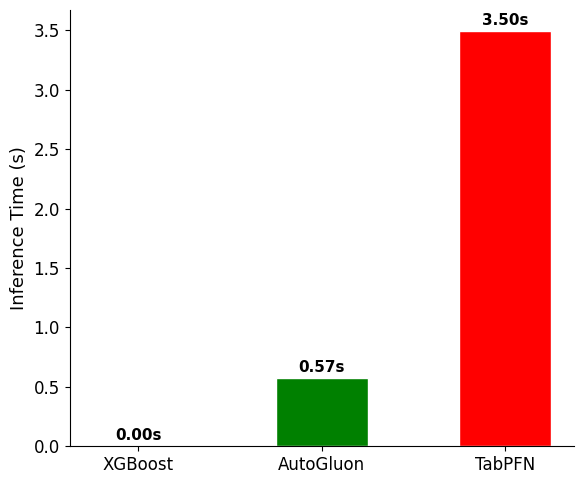

In [13]:
# Figure 5: Inference time
fig, ax = plt.subplots(figsize=(6, 5))
models3 = ['XGBoost', 'AutoGluon', 'TabPFN']
colors3 = ['blue', 'green', 'red']
inf_means = [xgb_df['inference_time'].mean(), auto_df['inference_time'].mean(),
             tabpfn_df['inference_time'].mean()]
bars = ax.bar(models3, inf_means, color=colors3, edgecolor='white', width=0.5)
ax.set_ylabel('Inference Time (s)', fontsize=13)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, v in zip(bars, inf_means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
            f'{v:.2f}s', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/figure5_inference_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings

- TabPFN achieved the highest AUC-ROC among the baseline models.
- AutoGluon provided strong out-of-the-box performance with minimal manual configuration.
- Tuned XGBoost improved substantially over default XGBoost, showing that hyperparameter tuning is important for a fair comparison.
- XGBoost remained the most computationally efficient model in terms of inference time.